#### GOAL:
Produce graph figures on predicted amplitides (so make the predictions first)

In [1]:
import sys, os, importlib
package_path = os.path.abspath('../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

Original params:  [190  30   9]


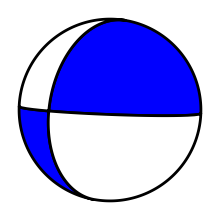

In [2]:
np.random.seed(2025)

# get true params for synthetic test
benchmark = (np.array([190, 30, 9]))
true_params = benchmark
print('Original params: ', true_params)

# plot corresponding beachball
beachball = fn.beachball(true_params)

# velocity model, assume depth, vp and vs cols
velocity_model = TauPyModel(model='ak135')
data_path = '../data/AK135_lookup.csv'
lookup_table = pd.read_csv(data_path)

In [3]:
catalog_df = pd.read_csv('out/catalog.csv')
az_epdist_tos_df = pd.read_csv('out/az_epdist_tos.csv')

# print colnames
print(catalog_df.columns)
print(az_epdist_tos_df.columns)

Index(['event_id', 'time', 'latitude', 'longitude', 'depth'], dtype='object')
Index(['Station', 'Azimuth', 'Epdist', 'P_Takeoff', 'S_Takeoff'], dtype='object')


In [4]:
eq_lat = catalog_df['latitude'].values[0]
eq_lon = catalog_df['longitude'].values[0]
hdepth = catalog_df['depth'].values[0]
velocities = fn.extract_velocities(lookup_table, hdepth)

def get_az_tos(df, station, deg=True):
    az = df[df['Station'] == station]['Azimuth'].values[0]
    p_to = 180 - df[df['Station'] == station]['P_Takeoff'].values[0]
    s_to = 180 - df[df['Station'] == station]['S_Takeoff'].values[0]
    if not deg:
        az = np.deg2rad(az)
        p_to = np.deg2rad(p_to)
        s_to = np.deg2rad(s_to)
    return az, p_to, s_to

# ANMO, COR, MSVF
anmo_az, anmo_p_to, anmo_s_to = get_az_tos(az_epdist_tos_df, 'ANMO', deg=False)
cor_az, cor_p_to, cor_s_to = get_az_tos(az_epdist_tos_df, 'COR', deg=False)
msvf_az, msvf_p_to, msvf_s_to = get_az_tos(az_epdist_tos_df, 'MSVF', deg=False)
kip_az, kip_p_to, kip_s_to = get_az_tos(az_epdist_tos_df, 'KIP', deg=False)

print(f"ANMO: az={anmo_az}, p_to={anmo_p_to}, s_to={anmo_s_to}")
print(f"COR: az={cor_az}, p_to={cor_p_to}, s_to={cor_s_to}")
print(f"MSVF: az={msvf_az}, p_to={msvf_p_to}, s_to={msvf_s_to}")
print(f"KIP: az={kip_az}, p_to={kip_p_to}, s_to={kip_s_to}")

ANMO: az=1.036155027552155, p_to=0.6087461429515179, s_to=0.6203709511694158
COR: az=0.682464456061232, p_to=0.6647603894652528, s_to=0.663797476417482
MSVF: az=3.7891745577949387, p_to=0.6180821194829196, s_to=0.627828212335541
KIP: az=5.556263702238507, p_to=1.540879603048976, s_to=1.5352259328556932


In [9]:
# general model for all predictions, add to out/pred_amps.csv
# loop throgh every station in the az_epdist_tos_df and generate predictions
# new df with cols station, p_amp, sv_amp, sh_amp
pred_amps_df = pd.DataFrame(columns=['Station', 'P_Amplitude', 'SV_Amplitude', 'SH_Amplitude'])

for station in az_epdist_tos_df['Station'].values:
    az, p_to, s_to = get_az_tos(az_epdist_tos_df, station, deg=False)
    gen_tos = np.array([p_to, s_to])
    gen_model = rm.RadiationModel(az, gen_tos, velocities)
    gen_Ao = gen_model(np.deg2rad(true_params), set_Ao=True, return_A=True)
    gen_model.reset()
    unit_Ao = fn.unit_vec(gen_Ao)
    pred_amps_df.loc[len(pred_amps_df)] = [station, unit_Ao[0], unit_Ao[1], unit_Ao[2]]

if not os.path.exists('out/pred_amps.csv'):
    pred_amps_df.to_csv('out/pred_amps.csv', index=False)

In [6]:
# ANMO try, COR try

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000
print_every = 10

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)


Using sdr parameters.


In [7]:
np.random.seed(13)

# initialize model
anmo_tos = np.array([anmo_p_to, anmo_s_to])
anmo_model = rm.RadiationModel(np.deg2rad(anmo_az), anmo_tos, velocities)
anmo_Ao = anmo_model(np.deg2rad(true_params), set_Ao=True, return_A=True)
anmo_model.reset()

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(anmo_model, config, start)

print(f'Convergence rate: {anmo_model.get_convergence_rate():.0f}%')


Run 0 of 50
Run 10 of 50


Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 96%


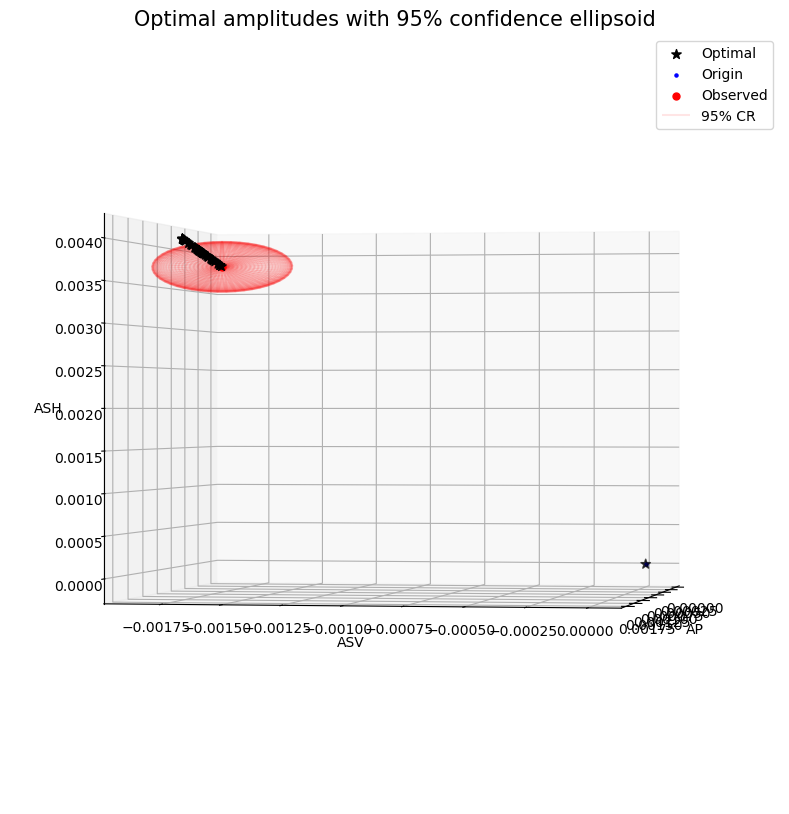

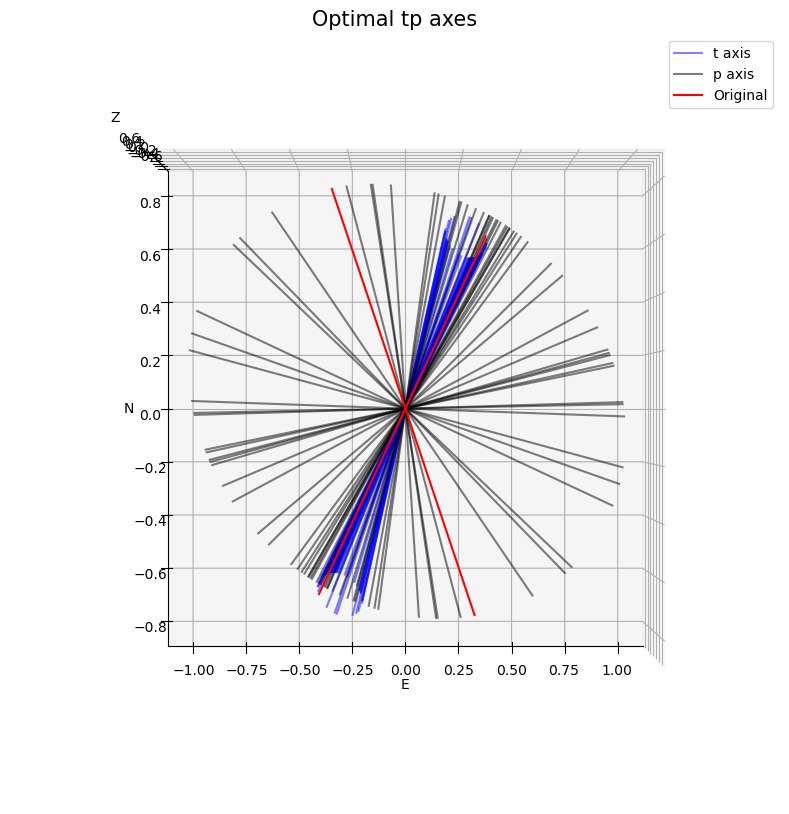

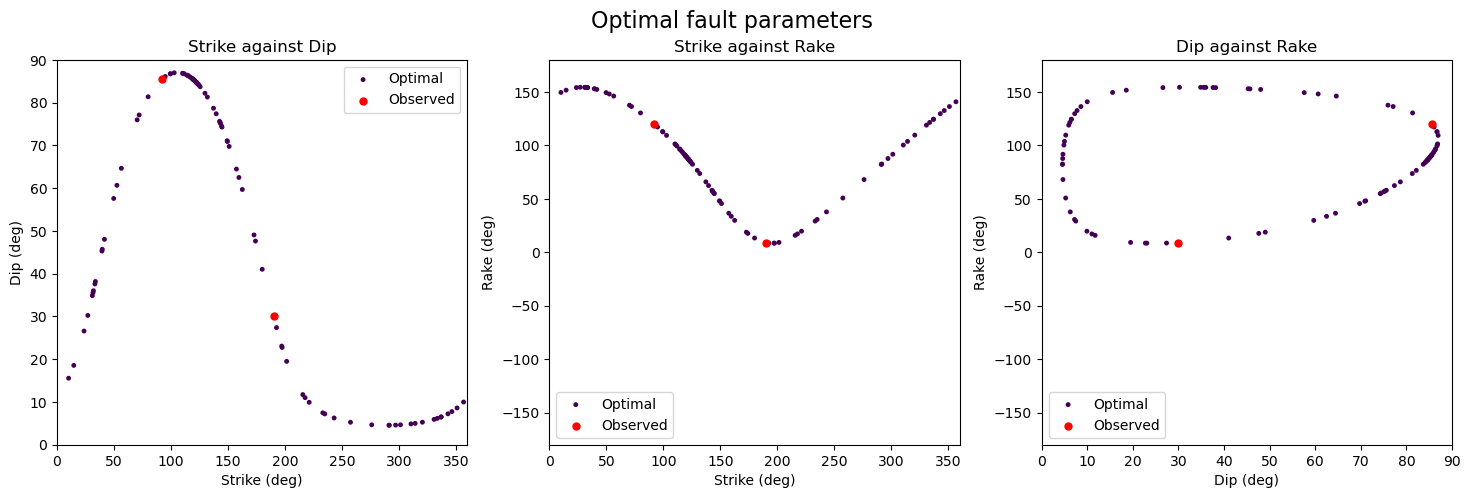

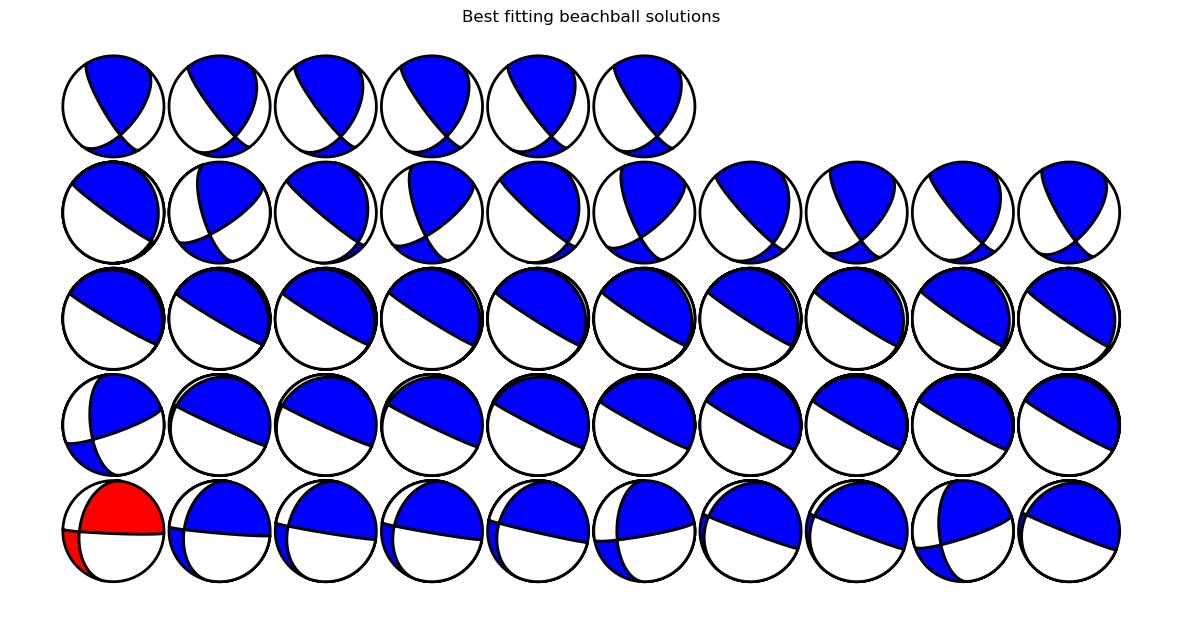

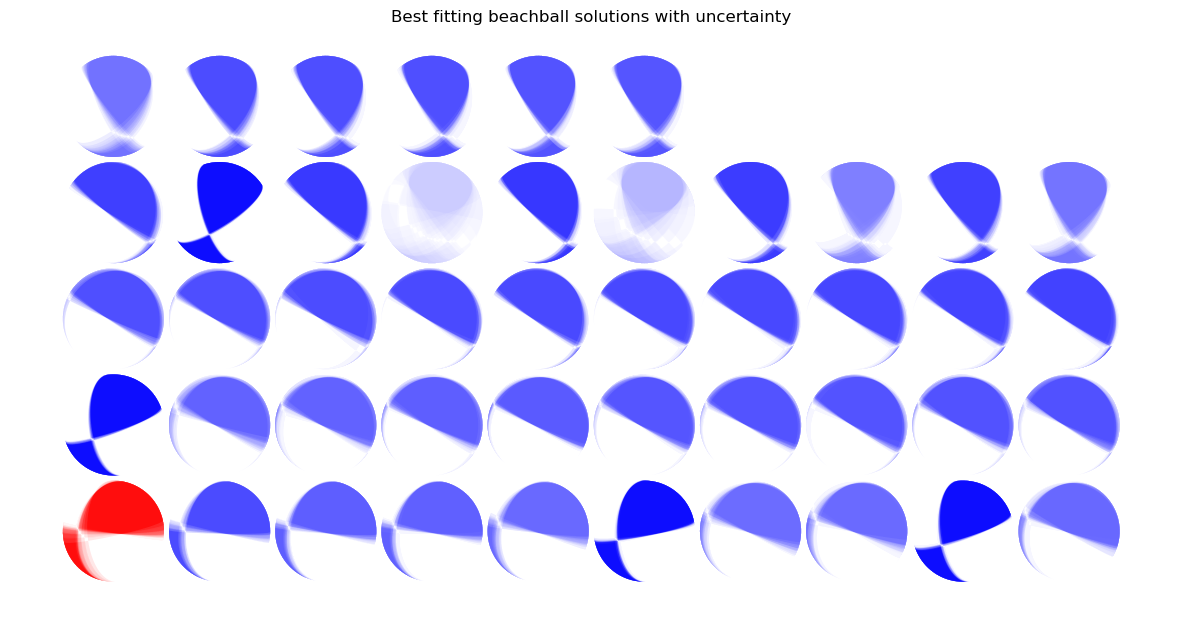

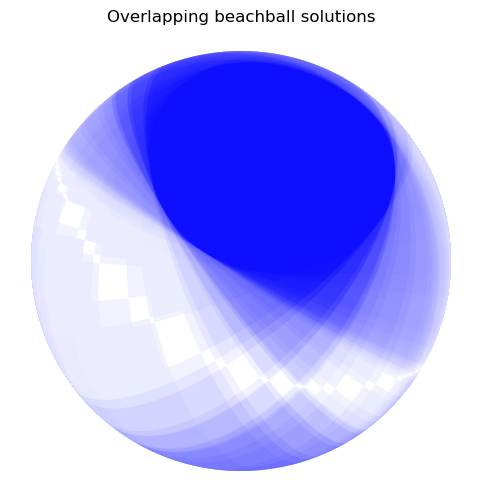

In [ ]:
# amplitude plot
anmo_model.reset_grid_amplitudes()
anmo_model.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(anmo_model, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(anmo_model, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(anmo_model, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(anmo_model, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(anmo_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
plots.beachballs(anmo_model, order_by='kagan', width=10,  max_plot=50,
                 original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(anmo_model, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

In [ ]:
np.random.seed(13)

# initialize model
cor_tos = np.array([cor_p_to, cor_s_to])
cor_model = rm.RadiationModel(np.deg2rad(cor_az), cor_tos, velocities)
cor_Ao = cor_model(np.deg2rad(true_params), set_Ao=True, return_A=True)
cor_model.reset()

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(cor_model, config, start)

print(f'Convergence rate: {cor_model.get_convergence_rate():.0f}%')

Run 0 of 50


Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 84%


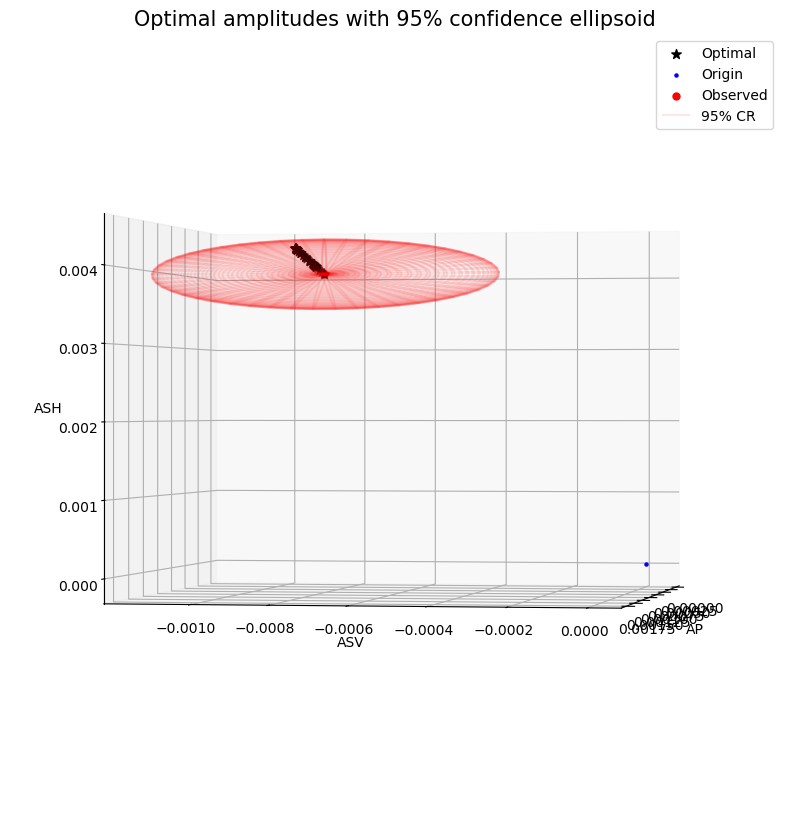

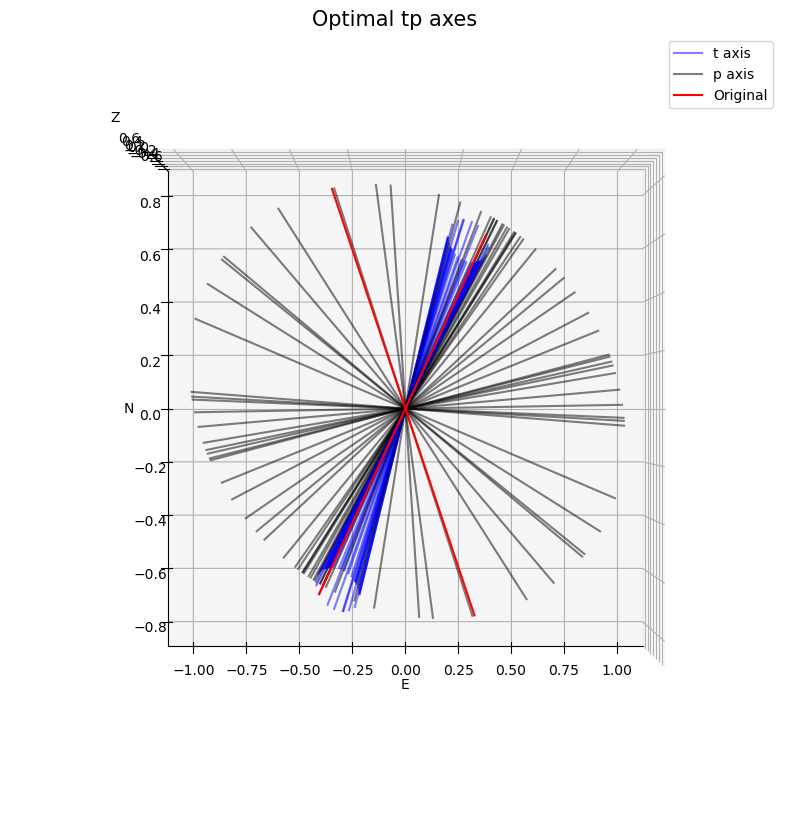

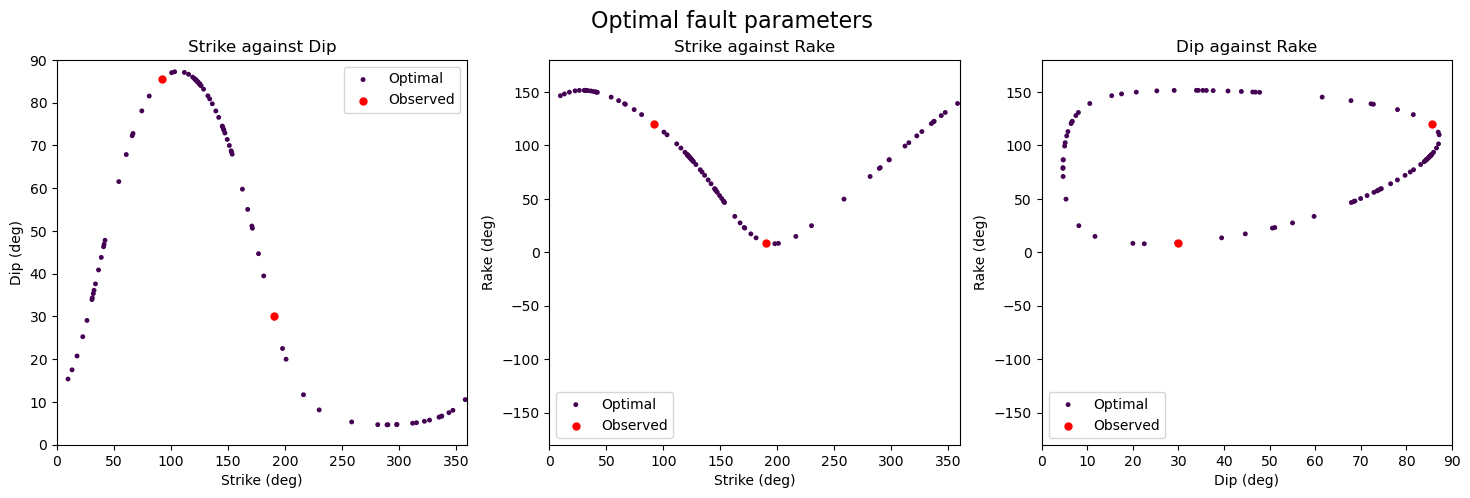

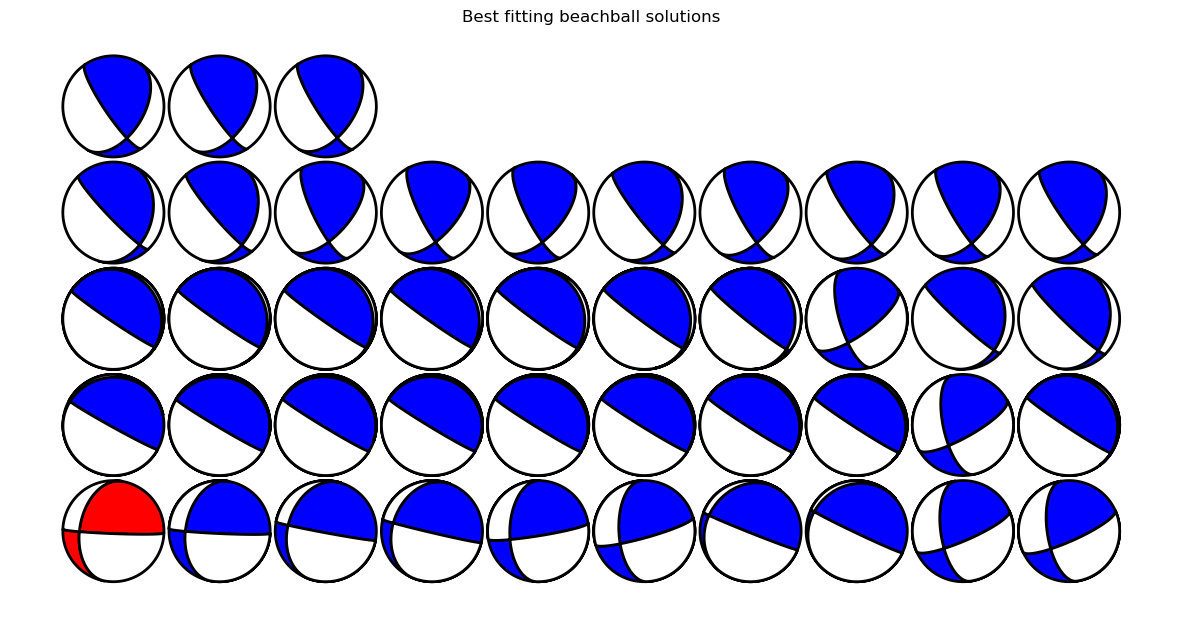

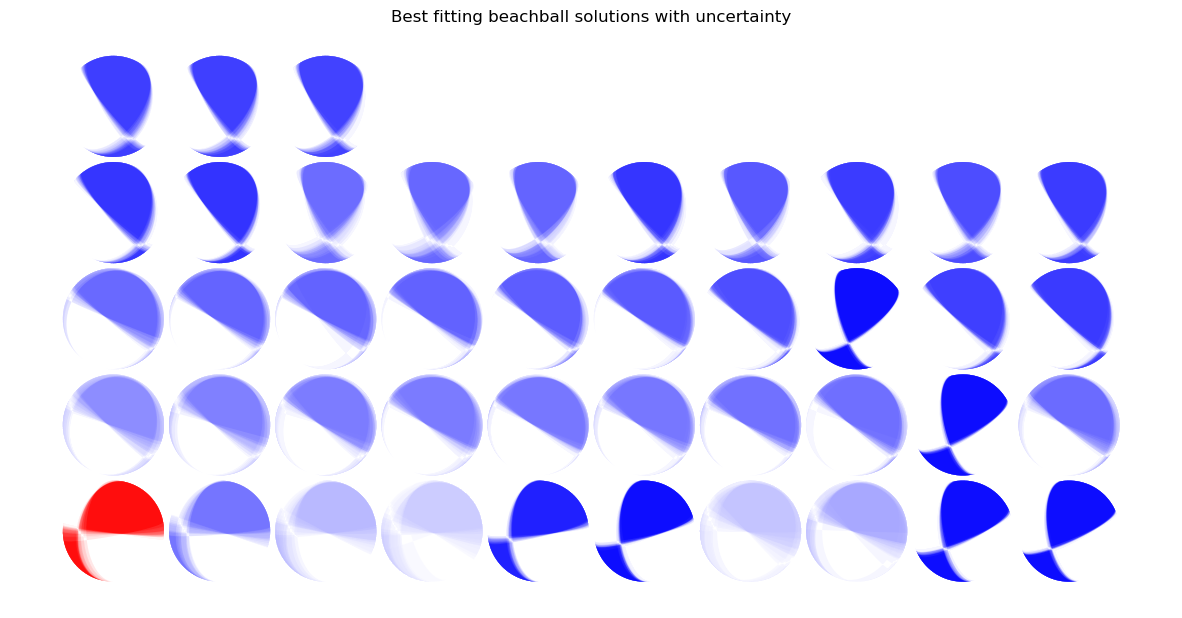

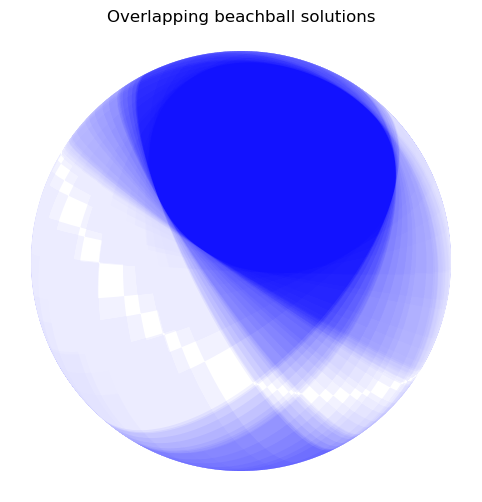

In [ ]:
# amplitude plot
cor_model.reset_grid_amplitudes()
cor_model.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(cor_model, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(cor_model, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(cor_model, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(cor_model, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(cor_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
plots.beachballs(cor_model, order_by='kagan', width=10,  max_plot=50,
                 original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(cor_model, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

In [ ]:
# MSVF try, KIP try

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 5000
config['misfit_tolerance'] = 1e-4
print_every = 10

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)


Using sdr parameters.


In [ ]:
np.random.seed(13)

# initialize model
msvf_tos = np.array([msvf_p_to, msvf_s_to])
msvf_model = rm.RadiationModel(np.deg2rad(msvf_az), msvf_tos, velocities)
msvf_Ao = msvf_model(np.deg2rad(true_params), set_Ao=True, return_A=True)
msvf_model.reset()

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(msvf_model, config, start)

print(f'Convergence rate: {msvf_model.get_convergence_rate():.0f}%')

Run 0 of 50


Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 96%


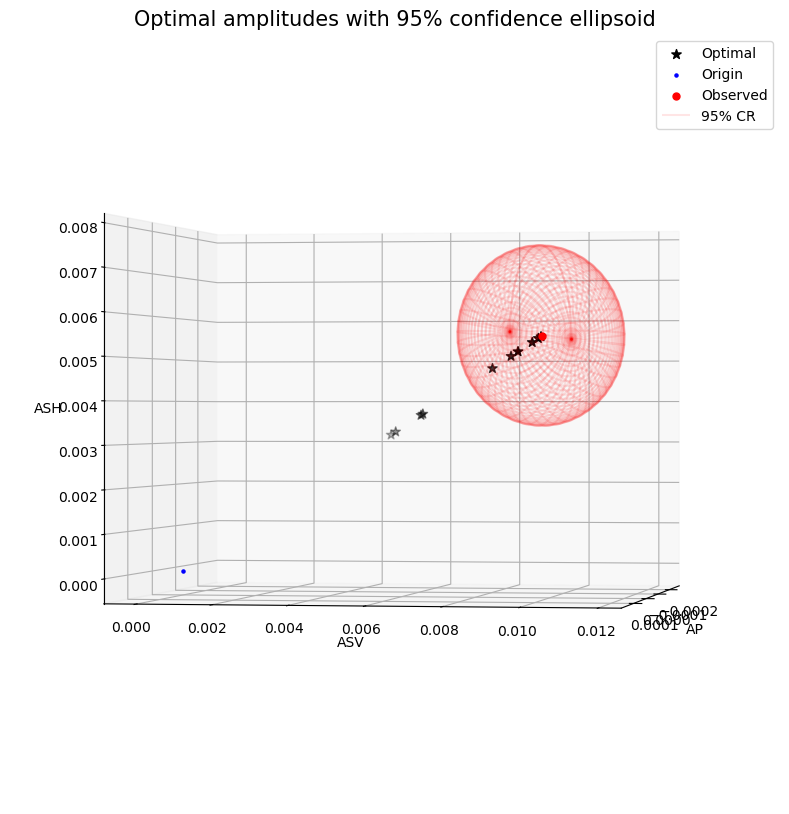

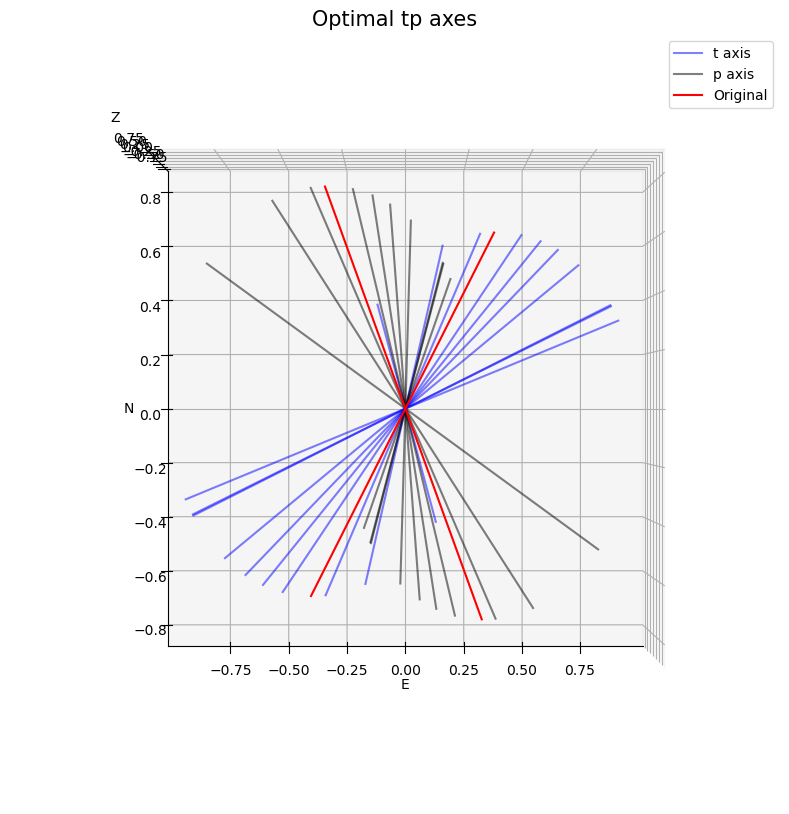

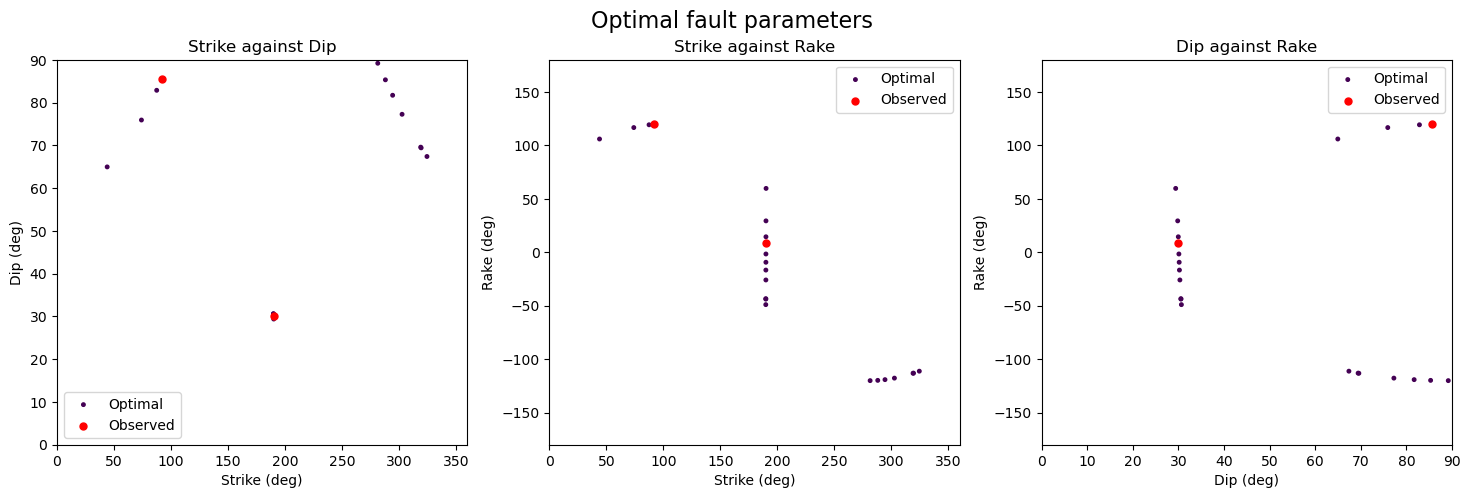

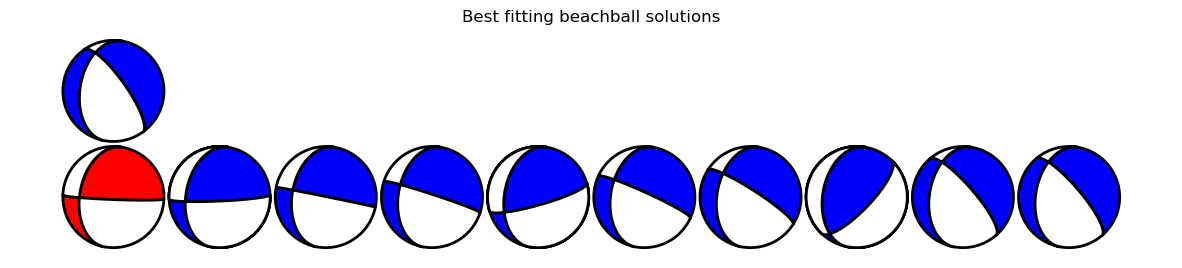

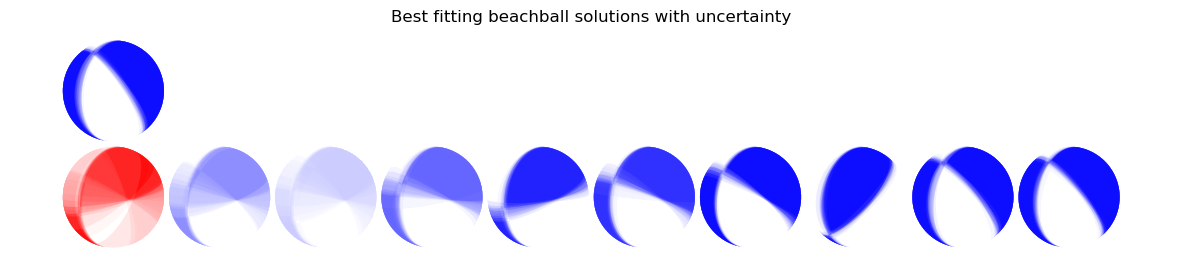

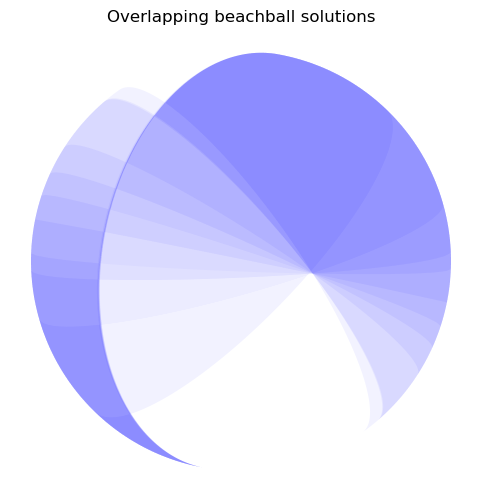

In [ ]:
# amplitude plot
msvf_model.reset_grid_amplitudes()
msvf_model.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(msvf_model, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(msvf_model, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(msvf_model, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(msvf_model, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(msvf_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
plots.beachballs(msvf_model, order_by='kagan', width=10,  max_plot=50,
                 original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(msvf_model, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

In [ ]:
np.random.seed(13)

# initialize model
kip_tos = np.array([kip_p_to, kip_s_to])
kip_model = rm.RadiationModel(np.deg2rad(kip_az), kip_tos, velocities)
kip_Ao = kip_model(np.deg2rad(true_params), set_Ao=True, return_A=True)
kip_model.reset()

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(kip_model, config, start)

print(f'Convergence rate: {kip_model.get_convergence_rate():.0f}%')


In [ ]:
# amplitude plot
kip_model.reset_grid_amplitudes()
kip_model.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(kip_model, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(kip_model, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(kip_model, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(kip_model, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(kip_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
plots.beachballs(kip_model, order_by='kagan', width=10,  max_plot=50,
                 original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(kip_model, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

In [ ]:
anmo_Ao_unit = fn.unit_vec(anmo_Ao)
cor_Ao_unit = fn.unit_vec(cor_Ao)
msvf_Ao_unit = fn.unit_vec(msvf_Ao)
kip_Ao_unit = fn.unit_vec(kip_Ao)
print(f"ANMO Ao unit vector: {anmo_Ao_unit}")
print(f"COR Ao unit vector: {cor_Ao_unit}")
print(f"MSVF Ao unit vector: {msvf_Ao_unit}")

ANMO Ao unit vector: [ 0.3767 -0.3615  0.8529]
COR Ao unit vector: [ 0.384  -0.1618  0.909 ]
MSVF Ao unit vector: [-0.0044  0.8666  0.499 ]
